In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [2]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

print(nav.head())
print(benchmark.head())

   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869
3     119551 2022-01-06  55.4550
4     119551 2022-01-07  55.3692
        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05
3 2022-01-06    NIFTY50     17878.51
4 2022-01-07    NIFTY50     17759.15


In [3]:
nav = nav.sort_values(
    ['amfi_code','date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

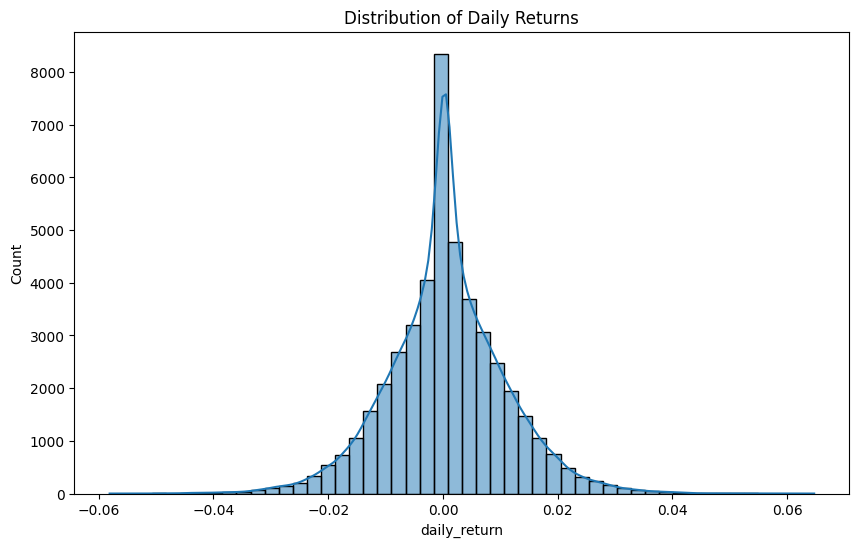

In [4]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.show()

In [5]:
nav['date'].min(), nav['date'].max()

(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [6]:
RF = 0.065

In [7]:
sharpe_results = []

for code, df in nav.groupby('amfi_code'):

    mean_daily = df['daily_return'].mean()
    std_daily = df['daily_return'].std()

    sharpe = (
        ((mean_daily * 252) - RF)
        /
        (std_daily * np.sqrt(252))
    )

    sharpe_results.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=['amfi_code','sharpe']
)

sharpe_df.sort_values(
    'sharpe',
    ascending=False
).head()

,amfi_code,sharpe
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [8]:
sortino_results = []

for code, df in nav.groupby('amfi_code'):

    downside = df[
        df['daily_return'] < 0
    ]['daily_return']

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        df['daily_return'].mean()
        * 252
    )

    sortino = (
        annual_return - RF
    ) / downside_std

    sortino_results.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=['amfi_code','sortino']
)

In [9]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [10]:
nav['date'].min(), nav['date'].max()

(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [11]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years) - 1) * 100

1-YEAR CAGR

In [12]:
cagr_1y = []

latest_date = nav['date'].max()

for code, df in nav.groupby('amfi_code'):

    df = df.sort_values('date')

    end_date = df['date'].max()
    start_date = end_date - pd.DateOffset(years=1)

    recent = df[df['date'] >= start_date]

    if len(recent) > 1:

        start_nav = recent.iloc[0]['nav']
        end_nav = recent.iloc[-1]['nav']

        cagr = calculate_cagr(
            start_nav,
            end_nav,
            1
        )

        cagr_1y.append([code, cagr])

cagr1_df = pd.DataFrame(
    cagr_1y,
    columns=['amfi_code','cagr_1y']
)

3-YEAR CAGR

In [13]:
cagr_3y = []

for code, df in nav.groupby('amfi_code'):

    df = df.sort_values('date')

    end_date = df['date'].max()
    start_date = end_date - pd.DateOffset(years=3)

    recent = df[df['date'] >= start_date]

    if len(recent) > 1:

        start_nav = recent.iloc[0]['nav']
        end_nav = recent.iloc[-1]['nav']

        cagr = calculate_cagr(
            start_nav,
            end_nav,
            3
        )

        cagr_3y.append([code, cagr])

cagr3_df = pd.DataFrame(
    cagr_3y,
    columns=['amfi_code','cagr_3y']
)

In [14]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [15]:
benchmark = benchmark.sort_values(
    ['index_name', 'date']
)

benchmark['benchmark_return'] = (
    benchmark.groupby('index_name')['close_value']
             .pct_change()
)

In [16]:
nifty100 = benchmark[
    benchmark['index_name'].str.contains(
        'Nifty 100',
        case=False,
        na=False
    )
].copy()

In [17]:
nifty100.head()

,date,index_name,close_value,benchmark_return


In [18]:
alpha_beta_results = []

for code, fund_df in nav.groupby('amfi_code'):

    merged = pd.merge(
        fund_df[['date','daily_return']],
        nifty100[['date','benchmark_return']],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) > 30:

        beta, alpha, r, p, std_err = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        annual_alpha = alpha * 252

        alpha_beta_results.append([
            code,
            annual_alpha,
            beta
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta


In [19]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [20]:
max_dd_results = []

for code, df in nav.groupby('amfi_code'):

    df = df.sort_values('date')

    running_max = df['nav'].cummax()

    drawdown = (
        df['nav'] / running_max
    ) - 1

    max_dd = drawdown.min()

    max_dd_results.append([
        code,
        max_dd
    ])

max_dd_df = pd.DataFrame(
    max_dd_results,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

max_dd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [21]:
scorecard = (
    cagr3_df
    .merge(sharpe_df,on='amfi_code')
    .merge(alpha_beta_df,on='amfi_code')
    .merge(max_dd_df,on='amfi_code')
)

In [22]:
scorecard['return_rank'] = scorecard['cagr_3y'].rank(pct=True)
scorecard['sharpe_rank'] = scorecard['sharpe'].rank(pct=True)
scorecard['alpha_rank'] = scorecard['alpha'].rank(pct=True)
scorecard['dd_rank'] = (-scorecard['max_drawdown']).rank(pct=True)

In [23]:
scorecard['fund_score'] = (
      scorecard['return_rank'] * 30
    + scorecard['sharpe_rank'] * 25
    + scorecard['alpha_rank'] * 20
    + scorecard['dd_rank'] * 10
)

scorecard['fund_score'] = (
    scorecard['fund_score']
    .round(2)
)

In [24]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [25]:
top5 = scorecard.sort_values(
    'fund_score',
    ascending=False
).head(5)

top5_codes = top5['amfi_code'].tolist()

In [26]:
print(top5_codes)

[]


In [27]:
for code in top5_codes:
    temp = nav[nav['amfi_code'] == code]
    print(code, len(temp))

In [28]:
nav['amfi_code'] = nav['amfi_code'].astype(str)
top5_codes = top5['amfi_code'].astype(str).tolist()

C:\Users\srini\AppData\Local\Temp\ipykernel_3928\1603860878.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


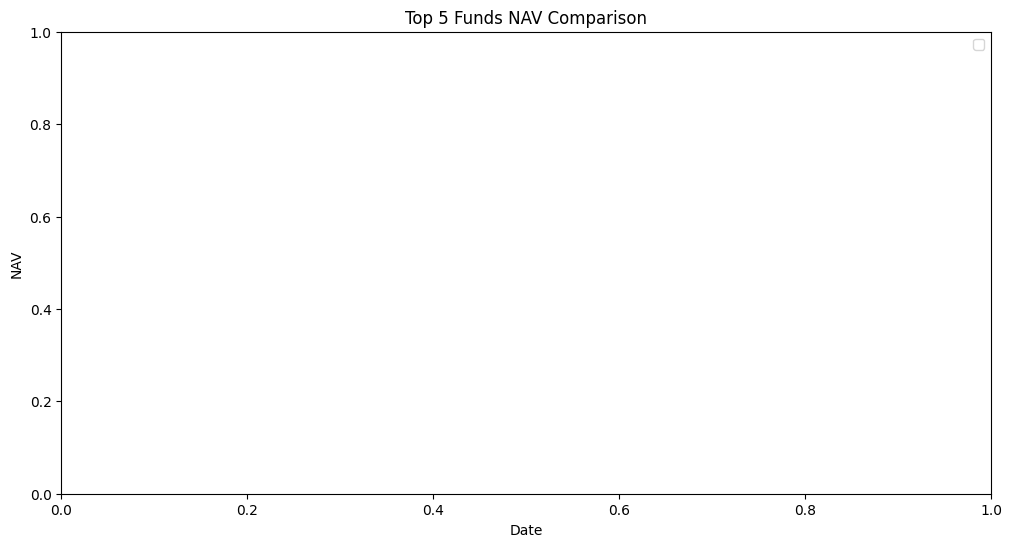

In [29]:
plt.figure(figsize=(12,6))

for code in top5_codes:

    temp = nav[
        nav['amfi_code'] == code
    ]

    plt.plot(
        temp['date'],
        temp['nav'],
        label=code
    )

plt.title("Top 5 Funds NAV Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.show()

In [30]:
print(nav.shape)
print(nav.head())
print(top5_codes)

(46000, 4)
     amfi_code       date       nav  daily_return
5750    100016 2022-01-03  520.4608           NaN
5751    100016 2022-01-04  515.0971     -0.010306
5752    100016 2022-01-05  521.7239      0.012865
5753    100016 2022-01-06  515.7880     -0.011377
5754    100016 2022-01-07  515.1639     -0.001210
[]


In [31]:
for code in top5_codes:
    temp = nav[nav['amfi_code'] == code]
    print(code, len(temp))

In [32]:
nav['amfi_code'] = nav['amfi_code'].astype(str)
top5['amfi_code'] = top5['amfi_code'].astype(str)

top5_codes = top5['amfi_code'].tolist()

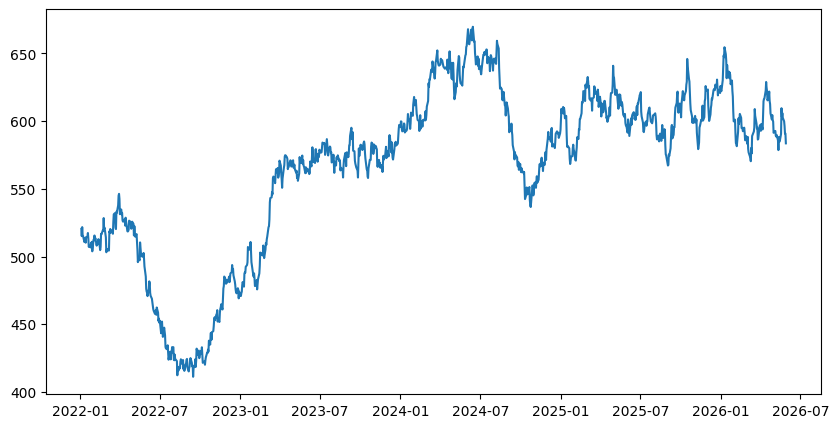

In [33]:
plt.figure(figsize=(10,5))

one_fund = nav[
    nav['amfi_code'] == nav['amfi_code'].iloc[0]
]

plt.plot(one_fund['date'], one_fund['nav'])
plt.show()

In [34]:
top5_codes = []

In [35]:
print(scorecard.shape)
scorecard.head()

(0, 11)


,amfi_code,cagr_3y,sharpe,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,dd_rank,fund_score


In [36]:
top5 = scorecard.sort_values(
    'fund_score',
    ascending=False
).head(5)

print(top5)


Empty DataFrame
Columns: [amfi_code, cagr_3y, sharpe, alpha, beta, max_drawdown, return_rank, sharpe_rank, alpha_rank, dd_rank, fund_score]
Index: []


In [37]:
print(cagr3_df.shape)
print(sharpe_df.shape)
print(alpha_beta_df.shape)
print(max_dd_df.shape)

(40, 2)
(40, 2)
(0, 3)
(40, 2)


In [38]:
scorecard = (
    cagr3_df
    .merge(sharpe_df,on='amfi_code')
    .merge(alpha_beta_df,on='amfi_code')
    .merge(max_dd_df,on='amfi_code')
)

In [39]:
cagr3_df['amfi_code'] = cagr3_df['amfi_code'].astype(str)
sharpe_df['amfi_code'] = sharpe_df['amfi_code'].astype(str)
alpha_beta_df['amfi_code'] = alpha_beta_df['amfi_code'].astype(str)
max_dd_df['amfi_code'] = max_dd_df['amfi_code'].astype(str)

In [40]:
scorecard = (
    cagr3_df
    .merge(sharpe_df,on='amfi_code')
    .merge(alpha_beta_df,on='amfi_code')
    .merge(max_dd_df,on='amfi_code')
)

print(scorecard.shape)

(0, 6)


In [41]:
print(scorecard.shape)
print(cagr3_df.shape)
print(sharpe_df.shape)
print(alpha_beta_df.shape)
print(max_dd_df.shape)

(0, 6)
(40, 2)
(40, 2)
(0, 3)
(40, 2)


In [42]:
benchmark['index_name'].unique()

<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str

In [43]:
benchmark = benchmark.sort_values(
    ['index_name','date']
)

benchmark['benchmark_return'] = (
    benchmark.groupby('index_name')['close_value']
             .pct_change()
)

In [44]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

In [45]:
from scipy.stats import linregress

alpha_beta_results = []

for code, fund_df in nav.groupby('amfi_code'):

    merged = pd.merge(
        fund_df[['date','daily_return']],
        nifty100[['date','benchmark_return']],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) > 30:

        beta, alpha, r, p, std_err = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        alpha_beta_results.append([
            str(code),
            alpha * 252,
            beta
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

print(alpha_beta_df.shape)
alpha_beta_df.head()

(40, 3)


,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [46]:
cagr3_df['amfi_code'] = cagr3_df['amfi_code'].astype(str)
sharpe_df['amfi_code'] = sharpe_df['amfi_code'].astype(str)
alpha_beta_df['amfi_code'] = alpha_beta_df['amfi_code'].astype(str)
max_dd_df['amfi_code'] = max_dd_df['amfi_code'].astype(str)

In [47]:
scorecard = (
    cagr3_df
    .merge(sharpe_df,on='amfi_code')
    .merge(alpha_beta_df,on='amfi_code')
    .merge(max_dd_df,on='amfi_code')
)

print(scorecard.shape)

(40, 6)


In [48]:
scorecard['return_rank'] = scorecard['cagr_3y'].rank(pct=True)
scorecard['sharpe_rank'] = scorecard['sharpe'].rank(pct=True)
scorecard['alpha_rank'] = scorecard['alpha'].rank(pct=True)
scorecard['dd_rank'] = (-scorecard['max_drawdown']).rank(pct=True)

scorecard['fund_score'] = (
    scorecard['return_rank'] * 30
    + scorecard['sharpe_rank'] * 25
    + scorecard['alpha_rank'] * 20
    + scorecard['dd_rank'] * 10
)

In [49]:
top5 = scorecard.sort_values(
    'fund_score',
    ascending=False
).head(5)

top5_codes = top5['amfi_code'].tolist()

print(top5_codes)

['120505', '148567', '148569', '119094', '100033']


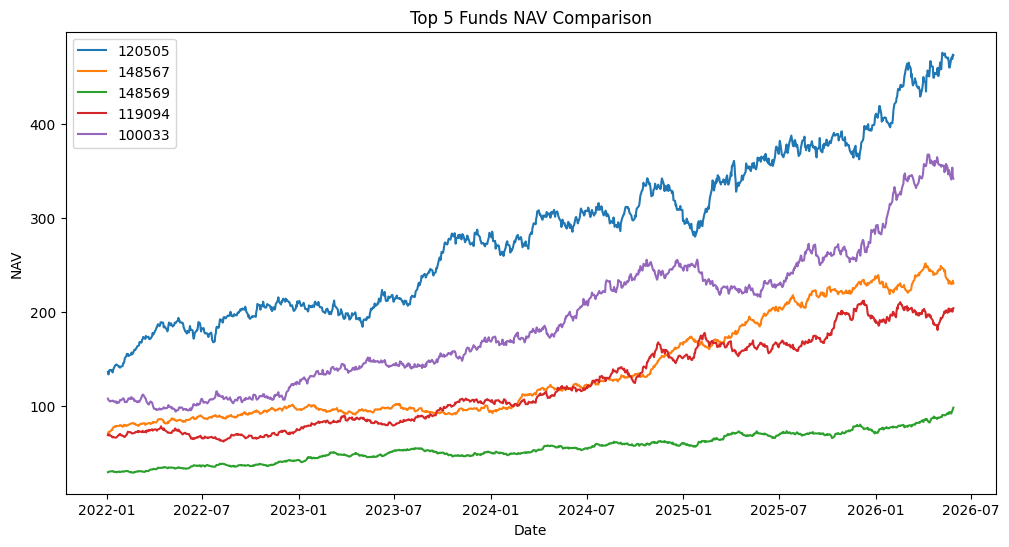

In [50]:
nav['amfi_code'] = nav['amfi_code'].astype(str)

plt.figure(figsize=(12,6))

for code in top5_codes:

    temp = nav[
        nav['amfi_code'] == code
    ]

    plt.plot(
        temp['date'],
        temp['nav'],
        label=code
    )

plt.title("Top 5 Funds NAV Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()

plt.show()

In [51]:
import pandas as pd

aum_clean = pd.read_csv(
    "../data/processed/aum_clean.csv"
)

aum_clean['date'] = pd.to_datetime(
    aum_clean['date']
)

In [52]:
aum_clean.groupby('date')['aum_lakh_crore'].sum()

date
2022-03-31    30.18
2022-09-30    30.90
2023-03-31    32.35
2023-09-30    37.42
2024-03-31    43.75
2024-09-30    47.27
2024-12-31    52.68
2025-03-31    54.47
2025-12-31    62.74
Name: aum_lakh_crore, dtype: float64

In [53]:
aum_clean.groupby('date')['aum_lakh_crore'].sum().tail()

date
2024-03-31    43.75
2024-09-30    47.27
2024-12-31    52.68
2025-03-31    54.47
2025-12-31    62.74
Name: aum_lakh_crore, dtype: float64

In [54]:
aum_clean.groupby('date')['aum_lakh_crore'].sum().max()

np.float64(62.74)

In [55]:
aum_clean.groupby('date')['aum_lakh_crore'].sum().idxmax()

Timestamp('2025-12-31 00:00:00')

In [56]:
aum_clean.groupby('date')['aum_lakh_crore'].sum().idxmax()

Timestamp('2025-12-31 00:00:00')

In [57]:
aum_clean.groupby('date')['aum_lakh_crore'].sum()

date
2022-03-31    30.18
2022-09-30    30.90
2023-03-31    32.35
2023-09-30    37.42
2024-03-31    43.75
2024-09-30    47.27
2024-12-31    52.68
2025-03-31    54.47
2025-12-31    62.74
Name: aum_lakh_crore, dtype: float64

In [ ]:
import pandas as pd

fund_scorecard = pd.read_csv(
    "../data/processed/fund_scorecard.csv"
)

In [ ]:
fund_scorecard.columns

Index(['amfi_code', 'cagr_3y', 'sharpe', 'alpha', 'beta', 'max_drawdown',
       'return_rank', 'sharpe_rank', 'alpha_rank', 'dd_rank', 'fund_score'],
      dtype='str')